# 06_MobileNet_NoiseEval

기존 MobileNetV2(노이즈 없는 원본으로 학습)를 노이즈 이미지에 적용했을 때의 성능 평가.

- 모델: `best_mobilenet.pth` (원본 이미지 학습)
- 입력: `noise_pic/noise_selected/` 노이즈 이미지
- 노이즈 종류별 분리 평가: full_mixed / fume_smoke / vibration
- 지표: Accuracy / Weighted F1 / Macro F1 / ROC-AUC / PR-AUC

In [1]:
from pathlib import Path
import torch

BASE_DIR       = Path.home() / 'Desktop' / 'ai1' / 'noise_target'
NOISE_PIC_DIR  = BASE_DIR / 'noise_pic' / 'noise_selected'
MOBILENET_PATH = BASE_DIR / 'best_mobilenet.pth'
LABEL_TXT      = BASE_DIR / 'original_INC_202501' / 'label_mapping.txt'

IMG_SIZE    = 224
THRESHOLD   = 0.5
RANDOM_SEED = 42

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


In [2]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    f1_score, precision_score, recall_score
)

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# 노이즈 종류 자동 탐색
NOISE_TYPES = sorted({
    d.name
    for trial_dir in NOISE_PIC_DIR.iterdir() if trial_dir.is_dir()
    for d in trial_dir.iterdir() if d.is_dir()
})
print(f'노이즈 종류: {NOISE_TYPES}')

노이즈 종류: ['full_mixed', 'fume_smoke', 'vibration']


In [3]:
# MobileNetV2 로드
mobilenet = models.mobilenet_v2(weights=None)
mobilenet.classifier[1] = nn.Linear(mobilenet.last_channel, 2)
mobilenet.load_state_dict(
    torch.load(str(MOBILENET_PATH), map_location=DEVICE, weights_only=True))
mobilenet = mobilenet.to(DEVICE).eval()

tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

@torch.no_grad()
def predict(img_path):
    """이미지 1장 → 이상 확률 softmax[:, 1]"""
    img = tf(Image.open(img_path).convert('RGB')).unsqueeze(0).to(DEVICE)
    return float(torch.softmax(mobilenet(img), dim=1)[0, 1].cpu())

print(f'MobileNetV2 로드 완료: {MOBILENET_PATH.name}')

MobileNetV2 로드 완료: best_mobilenet.pth


In [4]:
# 파일명 파싱 (label, trial_prefix, time_sec)
def parse_noise_image(img_path):
    stem       = img_path.stem
    trial_full = img_path.parent.parent.name
    mp = re.match(r'^((?:Test|Val))(\d+)', trial_full, re.IGNORECASE)
    if not mp: return None
    trial_prefix = mp.group(1).capitalize() + mp.group(2)
    ml = re.match(r'^label(\d+)_', stem)
    if not ml: return None
    label = int(ml.group(1))
    mt = re.search(r'_t(\d+\.?\d*)s_', stem)
    if not mt: return None
    return trial_prefix, float(mt.group(1)), label

print('파싱 함수 정의 완료')

파싱 함수 정의 완료


In [5]:
# 노이즈 종류별 추론
def run_experiment(noise_type):
    img_paths = sorted(NOISE_PIC_DIR.glob(f'*/{noise_type}/*.png'))
    rows = []
    skipped = 0
    for img_path in img_paths:
        info = parse_noise_image(img_path)
        if info is None: continue
        trial_prefix, time_sec, label = info
        if label not in (0, 1):   # label=2(검정화면) 제외
            skipped += 1
            continue
        prob = predict(img_path)
        pred = int(prob >= THRESHOLD)
        rows.append({
            'filename':     img_path.name,
            'trial':        trial_prefix,
            'time_sec':     time_sec,
            'label':        label,
            'prob':         round(prob, 4),
            'pred':         pred,
            'correct':      int(pred == label),
        })
    df = pd.DataFrame(rows)
    print(f'[{noise_type}]  처리={len(df)}장  스킵(검정화면)={skipped}장')
    return df


results = {}
for nt in NOISE_TYPES:
    results[nt] = run_experiment(nt)
print('\n추론 완료')

[full_mixed]  처리=1265장  스킵(검정화면)=129장
[fume_smoke]  처리=1432장  스킵(검정화면)=144장
[vibration]  처리=1426장  스킵(검정화면)=158장

추론 완료


In [6]:
# 노이즈 종류별 평가
def evaluate(df, noise_type):
    y_true = df['label'].values
    y_pred = df['pred'].values
    y_prob = df['prob'].values

    print(f'\n{"="*55}')
    print(f'  [{noise_type}]  n={len(df)}  '
          f'(정상={(y_true==0).sum()}  이상={(y_true==1).sum()})')
    print(f'{"="*55}')
    print(classification_report(y_true, y_pred,
                                labels=[0, 1],
                                target_names=['Normal(0)', 'Abnormal(1)'],
                                zero_division=0))
    m = {
        'noise_type':  noise_type,
        'n':           len(df),
        'n_normal':    int((y_true==0).sum()),
        'n_abnormal':  int((y_true==1).sum()),
        'accuracy':    round((y_true == y_pred).mean(), 4),
        'weighted_f1': round(f1_score(y_true, y_pred, labels=[0,1], average='weighted', zero_division=0), 4),
        'macro_f1':    round(f1_score(y_true, y_pred, labels=[0,1], average='macro',    zero_division=0), 4),
        'precision':   round(precision_score(y_true, y_pred, labels=[0,1], average='weighted', zero_division=0), 4),
        'recall':      round(recall_score(y_true, y_pred,    labels=[0,1], average='weighted', zero_division=0), 4),
    }
    try:
        m['roc_auc'] = round(roc_auc_score(y_true, y_prob), 4)
        m['pr_auc']  = round(average_precision_score(y_true, y_prob), 4)
    except Exception:
        m['roc_auc'] = m['pr_auc'] = float('nan')
    print(f"  Accuracy={m['accuracy']:.4f}  W-F1={m['weighted_f1']:.4f}  "
          f"Macro-F1={m['macro_f1']:.4f}  ROC-AUC={m['roc_auc']:.4f}")
    return m


summary = []
for nt in NOISE_TYPES:
    summary.append(evaluate(results[nt], nt))

summary_df = pd.DataFrame(summary).set_index('noise_type')
print('\n\n=== 전체 요약 ===')
print(summary_df[['n','n_normal','n_abnormal','accuracy',
                   'weighted_f1','macro_f1','roc_auc','pr_auc']].to_string())


  [full_mixed]  n=1265  (정상=674  이상=591)
              precision    recall  f1-score   support

   Normal(0)       0.58      0.86      0.69       674
 Abnormal(1)       0.65      0.31      0.42       591

    accuracy                           0.60      1265
   macro avg       0.62      0.58      0.56      1265
weighted avg       0.62      0.60      0.56      1265

  Accuracy=0.5992  W-F1=0.5648  Macro-F1=0.5557  ROC-AUC=0.6324

  [fume_smoke]  n=1432  (정상=841  이상=591)
              precision    recall  f1-score   support

   Normal(0)       0.59      1.00      0.74       841
 Abnormal(1)       0.00      0.00      0.00       591

    accuracy                           0.59      1432
   macro avg       0.29      0.50      0.37      1432
weighted avg       0.34      0.59      0.43      1432

  Accuracy=0.5873  W-F1=0.4346  Macro-F1=0.3700  ROC-AUC=0.8685

  [vibration]  n=1426  (정상=835  이상=591)
              precision    recall  f1-score   support

   Normal(0)       0.82      0.88     

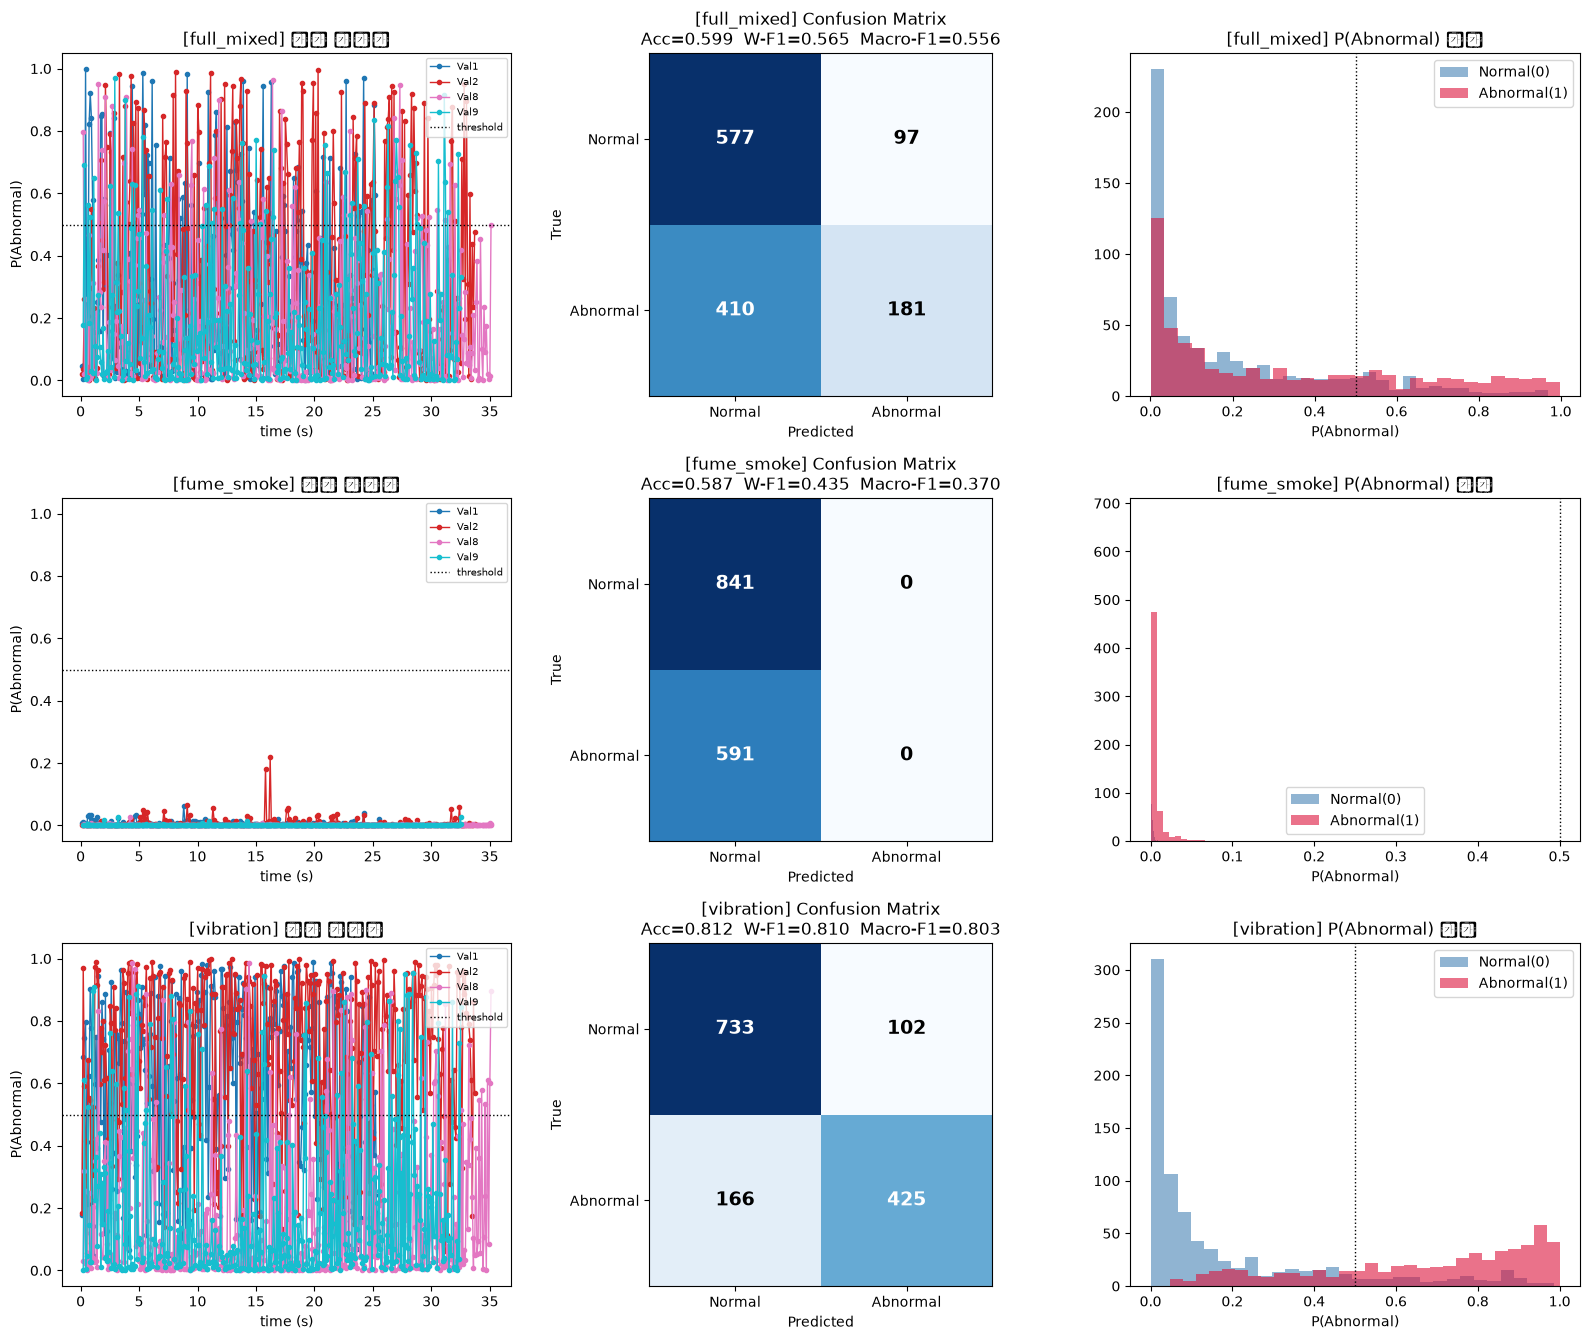

In [7]:
# 시각화
n_types = len(NOISE_TYPES)
fig, axes = plt.subplots(n_types, 3, figsize=(16, 4.5 * n_types))
if n_types == 1:
    axes = axes[np.newaxis, :]

for row, nt in enumerate(NOISE_TYPES):
    df = results[nt]

    # ── 확률 시계열 (trial별 색상) ───────────────────────────────
    ax = axes[row, 0]
    trials = df['trial'].unique()
    colors = plt.cm.tab10(np.linspace(0, 1, len(trials)))
    for trial, c in zip(trials, colors):
        grp = df[df['trial'] == trial].sort_values('time_sec')
        ax.plot(grp['time_sec'], grp['prob'], marker='o', ms=3,
                linewidth=1, color=c, label=trial)
    ax.axhline(THRESHOLD, color='k', linestyle=':', lw=1, label='threshold')
    ax.set_title(f'[{nt}] 확률 시계열')
    ax.set_xlabel('time (s)'); ax.set_ylabel('P(Abnormal)')
    ax.legend(fontsize=7); ax.set_ylim(-0.05, 1.05)

    # ── 혼동행렬 ─────────────────────────────────────────────────
    ax = axes[row, 1]
    y_true = df['label'].values; y_pred = df['pred'].values
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    ax.imshow(cm, cmap='Blues')
    ax.set(xticks=[0,1], yticks=[0,1],
           xticklabels=['Normal','Abnormal'],
           yticklabels=['Normal','Abnormal'],
           xlabel='Predicted', ylabel='True',
           title=f'[{nt}] Confusion Matrix\n'
                 f'Acc={summary_df.loc[nt,"accuracy"]:.3f}  '
                 f'W-F1={summary_df.loc[nt,"weighted_f1"]:.3f}  '
                 f'Macro-F1={summary_df.loc[nt,"macro_f1"]:.3f}')
    th = cm.max() / 2
    for i, j in itertools.product(range(2), range(2)):
        ax.text(j, i, str(cm[i,j]), ha='center', va='center',
                color='white' if cm[i,j] > th else 'black',
                fontsize=14, fontweight='bold')

    # ── 확률 분포 (정상 vs 이상) ─────────────────────────────────
    ax = axes[row, 2]
    ax.hist(df[df['label']==0]['prob'], bins=30, alpha=0.6,
            color='steelblue', label='Normal(0)')
    ax.hist(df[df['label']==1]['prob'], bins=30, alpha=0.6,
            color='crimson',   label='Abnormal(1)')
    ax.axvline(THRESHOLD, color='k', linestyle=':', lw=1)
    ax.set_title(f'[{nt}] P(Abnormal) 분포')
    ax.set_xlabel('P(Abnormal)'); ax.legend()

plt.tight_layout()
plt.savefig(str(BASE_DIR / 'mobilenet_noise_eval.png'), dpi=150)
plt.show()

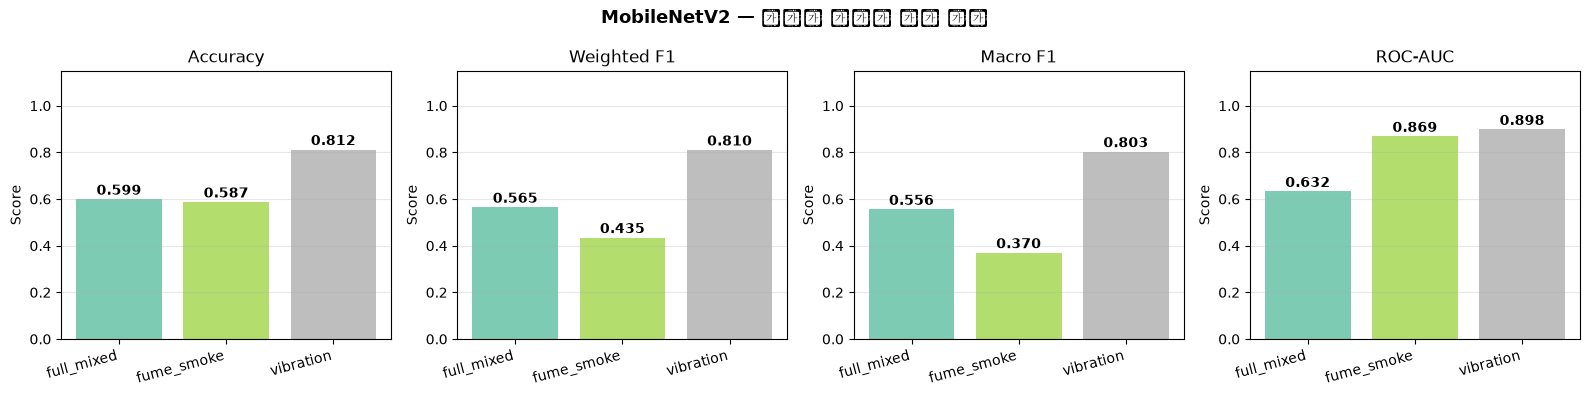


=== 최종 요약 표 ===
               n  accuracy  weighted_f1  macro_f1  roc_auc  pr_auc
noise_type                                                        
full_mixed  1265    0.5992       0.5648    0.5557   0.6324  0.6199
fume_smoke  1432    0.5873       0.4346    0.3700   0.8685  0.8117
vibration   1426    0.8121       0.8102    0.8029   0.8981  0.8382


In [8]:
# 노이즈 종류별 성능 비교 막대 그래프
metrics_cols  = ['accuracy', 'weighted_f1', 'macro_f1', 'roc_auc']
metrics_labels = ['Accuracy', 'Weighted F1', 'Macro F1', 'ROC-AUC']
fig, axes = plt.subplots(1, len(metrics_cols), figsize=(16, 4))
colors = plt.cm.Set2(np.linspace(0, 1, len(NOISE_TYPES)))

for ax, col, label in zip(axes, metrics_cols, metrics_labels):
    vals = [summary_df.loc[nt, col] for nt in NOISE_TYPES]
    bars = ax.bar(NOISE_TYPES, vals, color=colors, alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_ylim(0, 1.15)
    ax.set_title(label)
    ax.set_ylabel('Score')
    ax.grid(True, alpha=0.3, axis='y')
    plt.setp(ax.get_xticklabels(), rotation=15, ha='right')

plt.suptitle('MobileNetV2 — 노이즈 종류별 성능 비교', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(str(BASE_DIR / 'mobilenet_noise_comparison.png'), dpi=150)
plt.show()

print('\n=== 최종 요약 표 ===')
print(summary_df[['n','accuracy','weighted_f1','macro_f1','roc_auc','pr_auc']].to_string())